# Module 03: EDA

In [67]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [68]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [69]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [70]:
for col in Hitters.columns:
    print(col, Hitters[col].dtype)

AtBat int64
Hits int64
HmRun int64
Runs int64
RBI int64
Walks int64
Years int64
CAtBat int64
CHits int64
CHmRun int64
CRuns int64
CRBI int64
CWalks int64
League category
Division category
PutOuts int64
Assists int64
Errors int64
Salary float64
NewLeague category


### Before doing any other analyses, let's create training and test sets.

In [71]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The difference between the 6 columns starting with "C", and the 6 related columns that don't is that the indicates tehpdata points that were of just during one player's career, indicated by the "C".

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

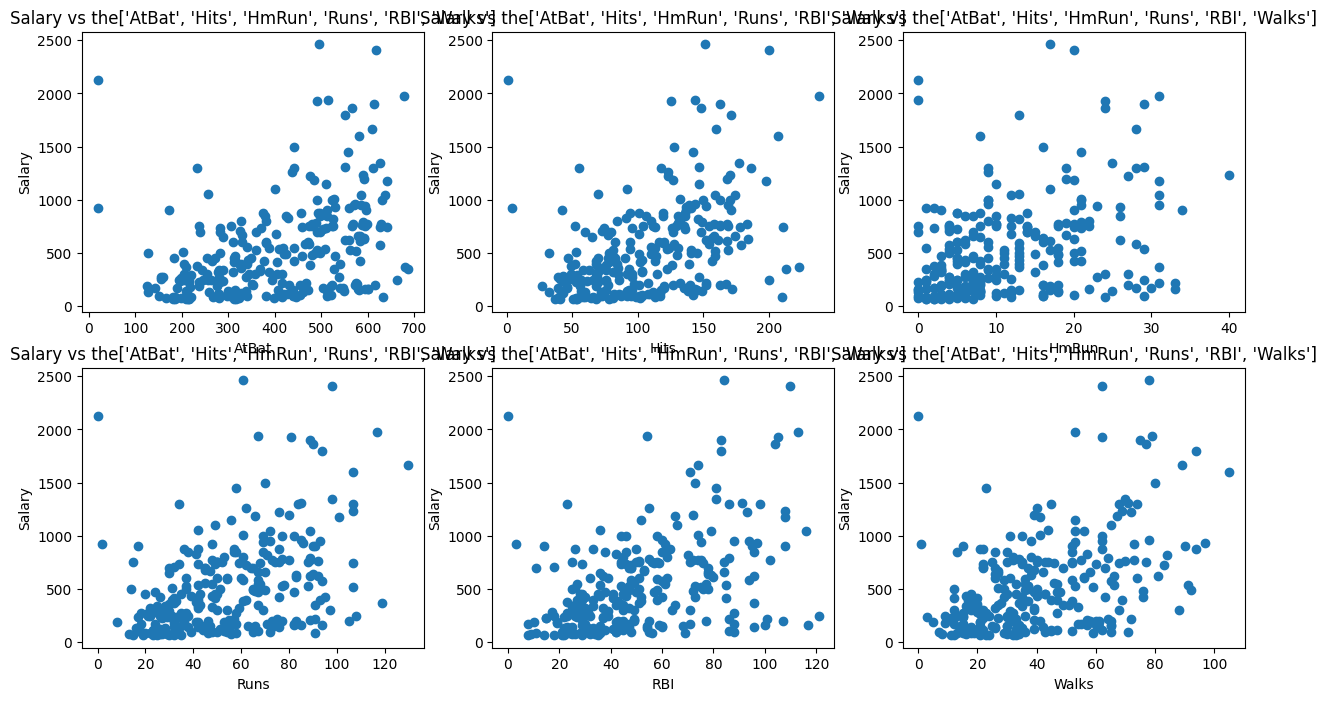

In [72]:
the_columns = ["AtBat", "Hits", "HmRun", "Runs", "RBI", "Walks"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(the_columns):
    axes[i].scatter(Hitters[col], Hitters["Salary"])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Salary")
    axes[i].set_title(f"Salary vs the{the_columns}")




### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [73]:
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

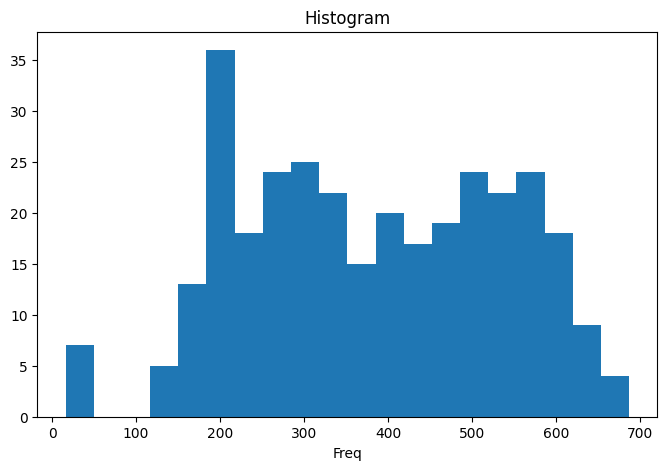

In [74]:
plt.figure(figsize=(8, 5))
plt.hist(Hitters["AtBat"], bins = 20)

plt.xlabel("Freq")
plt.title("Histogram")

plt.show()

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [75]:
atBat_mean = Train["AtBat"].mean()

atBat_stand = Train["AtBat"].std()

"""so now we will make it standarized"""
Train["AtBat_st"] = (Train["AtBat"] - atBat_mean) / atBat_stand


### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [76]:
len(Train[Train["AtBat_st"].between(-1,1)])

115

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

You can tell the "Salary" variable has missing values by the "count" value being less than the total number of rows in our "describe()" output.

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

This could happen is the missing values in the data were instead left left a filler values, such as 0, or a string like "N/A".

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

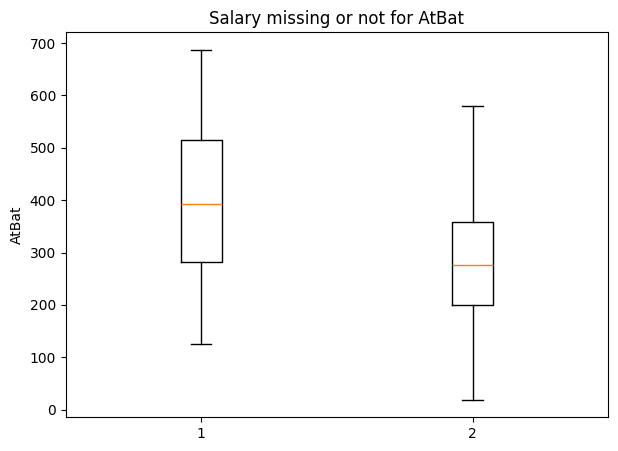

In [77]:
'''whether salary is missing or not'''
present_sal_AtBat = Train.loc[Train["Salary"].notna(), "AtBat"]
missing_sal_AtBat = Train.loc[Train["Salary"].isna(), "AtBat"]

'''setting the plot up'''
plt.figure(figsize=(7, 5))
plt.boxplot([present_sal_AtBat, missing_sal_AtBat])

plt.title("Salary missing or not for AtBat")

plt.ylabel("AtBat")
plt.show()

### Create a correlation matrix for all numeric features in the training set

In [78]:
training_num = Train.select_dtypes(include=np.number)

matrix_corr = training_num.corr()

print(matrix_corr)

             AtBat      Hits     HmRun      Runs       RBI     Walks  \
AtBat     1.000000  0.963324  0.540323  0.906579  0.798717  0.631824   
Hits      0.963324  1.000000  0.516853  0.914739  0.795316  0.605876   
HmRun     0.540323  0.516853  1.000000  0.618439  0.840613  0.385425   
Runs      0.906579  0.914739  0.618439  1.000000  0.786635  0.711346   
RBI       0.798717  0.795316  0.840613  0.786635  1.000000  0.553527   
Walks     0.631824  0.605876  0.385425  0.711346  0.553527  1.000000   
Years    -0.039232 -0.028717  0.009072 -0.069584  0.046705  0.037943   
CAtBat    0.126602  0.133316  0.078981  0.083770  0.165837  0.137157   
CHits     0.146763  0.163329  0.076914  0.103859  0.180526  0.147019   
CHmRun    0.150166  0.136865  0.411917  0.160979  0.375072  0.194766   
CRuns     0.164892  0.175542  0.110767  0.159683  0.191452  0.205250   
CRBI      0.145779  0.153011  0.218285  0.115628  0.285074  0.167453   
CWalks    0.056578  0.065178  0.080296  0.099025  0.117109  0.31

### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

1.We can use a regression model, using variables correleated with "Salary" to address the missing values. 2. Another idea is to group players by how they perform, and use mean salary for each interval, such as low, middle, high, to fill in those missing vals.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [79]:
TotHits = Train["Hits"].sum()
TotWalks = Train["Walks"].sum()
TotAtBat = Train["AtBat"].sum()

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

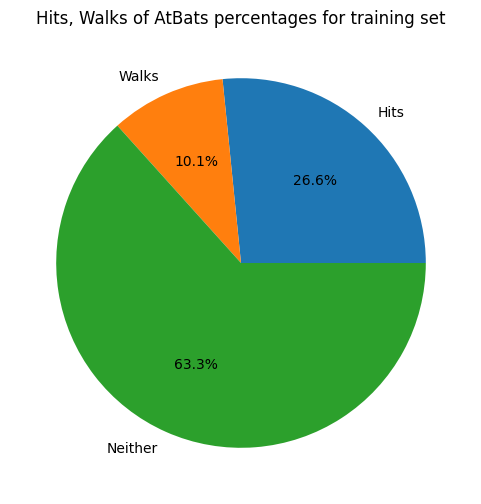

In [80]:
plt.figure(figsize = (6,6))
plt.pie(Totals, labels=Labels, autopct = "%1.1f%%")
plt.title("Hits, Walks of AtBats percentages for training set")

plt.show()

### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [81]:
Train["AVG"] = Train["Hits"] / Train["AtBat"]

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [82]:
Train['AVG_bin'] = 'medium'
Train['AVG_bin'][Train["AVG"] < 0.25] = "low"
Train['AVG_bin'][Train["AVG"] < 0.31] = "high"

C:\Users\ROSHN\AppData\Local\Temp\ipykernel_25824\3294042407.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  Train['AVG_bin'][Train["AVG"] < 0.25] = "low"
C:\Users\ROSHN\AppData\Local\Temp\ipykernel_25824\3294042407.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behav

### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

In [83]:
Train['AVG_bin'].value_counts()

AVG_bin
medium    193
Name: count, dtype: int64

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [84]:
indexMap = ['low', 'medium', 'high']
#reordered_list = [Train['AVG_bin'].value_counts(i) for i in indexMap]
reordered_list = Train['AVG_bin'].value_counts().reindex(indexMap, fill_value=0).tolist()

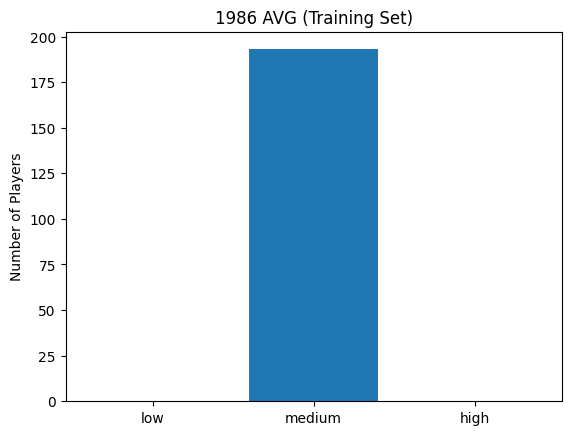

In [85]:
plt.bar(indexMap, reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(indexMap)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

We seemed to be using width method. This is very telling by the fact all of our players fall under our fixed mid range, with the cutoff for that section being .25-.31, which fits all our our players perfectly. 